# **Air Temperature Time Series Project**

**Made by:** **[Chinmay Shastry]** & **[Sharanya Makam]**

**Project team's ID:** **PTID-AI-FEB-26-1094**

**Project Code:** **PRAICP-1003-AirTempTS**

---

# 📊 Surface Air Temperature Forecasting Report

## 1. Objective
The objective of this project is to analyze and forecast monthly surface air temperature using both classical time-series models and modern machine learning approaches. The forecasting horizon covers the most recent 20% of the dataset, while the first 80% is used for training. Accurate forecasts can support:
- Climate analysis
- Energy demand planning
- Environmental policy decisions

**Models Compared:**
ARIMA, SARIMA, Prophet, XGBoost, Tuned XGBoost, LightGBM, Tuned LightGBM, Hybrid (SARIMA + XGBoost residual model)

**Goal:** Evaluate predictive performance and determine which modeling approach best captures temperature dynamics.

---

## 2. Data Description
- **Dataset:** Monthly Surface Air Temperature (°C)
- **Frequency:** Monthly
- **Target Variable:** mean_temp
- **Train-Test Split:** 80% Training, 20% Testing (chronological)

**Preprocessing Steps:**
- Converted month column to datetime format.
- Sorted data chronologically.
- Set date column as index.
- Enforced monthly frequency (MS).
- Removed missing values created during frequency alignment.

---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Trend Analysis
- Used rolling statistics (12-month rolling mean and rolling standard deviation).
- **Observations:**
  - Rolling mean shows gradual movement, indicating a long-term trend.
  - Rolling standard deviation remains stable, suggesting consistent variability.

### 3.2 Seasonal Decomposition
- Decomposed using an additive model with a 12-month period.
- **Components:**
  - **Trend:** Gradual long-term movement.
  - **Seasonal:** Repeating yearly pattern.
  - **Residual:** Irregular fluctuations.

### 3.3 Autocorrelation Analysis
- **ACF:** Significant correlations, especially at lag 12 (yearly seasonality).
- **PACF:** Direct relationships at different lags, suggesting autoregressive components.

---

## 4. Model Development

### ARIMA
- ARIMA(1,1,1) captures linear trend and short-term autocorrelation, but not seasonality.

### SARIMA
- SARIMA(1,1,1)(1,1,1,12) accounts for trend, seasonality, and autocorrelation.

### Prophet
- Captures trend, seasonality, and structural changes.
- Dataset converted to Prophet format (ds → date, y → temperature).

### Machine Learning Models
- **Lag Features:** Lag 1, 2, 3, 6, 12 used as predictors.
- **XGBoost:** Captures nonlinear relationships.
- **Tuned XGBoost:** Hyperparameters optimized via GridSearchCV and TimeSeriesSplit.
- **LightGBM:** Optimized for fast training and high performance.
- **Tuned LightGBM:** Hyperparameters optimized similarly.

### Hybrid Model (SARIMA + XGBoost)
- SARIMA generates baseline predictions.
- XGBoost predicts SARIMA residuals.
- Final prediction = SARIMA forecast + predicted residuals.

---

## 5. Model Evaluation Metrics
- **MAE, RMSE, MAPE, sMAPE** used for evaluation.
- **Primary Metric:** RMSE (penalizes larger errors more strongly).

---

## 6. Model Performance Results

| Model            | MAE   | RMSE  | MAPE  | sMAPE |
|------------------|-------|-------|-------|-------|
| Tuned LightGBM   | 0.4226| 0.5323| 1.51% | 1.51% |
| Tuned XGBoost    | 0.4437| 0.5412| 1.58% | 1.59% |
| LightGBM         | 0.4407| 0.5479| 1.57% | 1.58% |
| XGBoost          | 0.4519| 0.5494| 1.61% | 1.62% |
| Prophet          | 0.5193| 0.6617| 1.84% | 1.86% |
| SARIMA           | 0.5302| 0.6618| 1.88% | 1.90% |
| ARIMA            | 0.6271| 0.7572| 2.24% | 2.24% |
| Hybrid           | 0.6213| 0.7619| 2.20% | 2.23% |

---

## 7. Results & Interpretation
- **Best Model:** Tuned LightGBM (lowest RMSE and MAE).
- **Key Observations:**
  - Machine learning models outperform classical time-series models.
  - Lag features effectively capture temporal dependencies.
  - Hyperparameter tuning significantly improves ML performance.
  - Hybrid model did not outperform individual ML models.

---

## 8. Key Insights
- Temperature data contains seasonal patterns and temporal dependencies.
- Tree-based ML models effectively learn these patterns using lag features.
- Gradient boosting methods are particularly effective for structured time-series forecasting.

---

## 9. Conclusion
This project compared classical statistical models and modern ML methods for forecasting monthly surface air temperature.
- **Key Findings:**
  - Tuned LightGBM achieved the best predictive performance.
  - Gradient boosting models consistently outperformed ARIMA, SARIMA, and Prophet.
  - ML models benefit from lag features that capture historical temperature patterns.

---

## 10. Future Improvements
- Walk-forward validation instead of fixed split.
- Adding exogenous variables (humidity, CO₂ levels, ENSO index).
- Probabilistic forecasting with prediction intervals.
- Feature engineering with rolling statistics.
- Ensemble forecasting using multiple models.


## **Importing Libraries**

In [56]:
!pip install prophet lightgbm

In [57]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

np.random.seed(42)
sns.set_palette("Paired")

## **Load Dataset**

In [58]:
df = pd.read_csv("surface-air-temperature-monthly-mean.csv")

In [59]:
df['month'] = pd.to_datetime(df['month']) # converting the 'month' column into official datetime objects.
# This allows to perform time-based math, like extracting the year or calculating the difference between dates.

df = df.sort_values('month') # This ensures model sees the progression of time correctly from past to present.

df.set_index('month', inplace=True) # Moving the 'month' column to the DataFrame's index.

In [60]:
df = df.asfreq('MS') # "MS" stands for 'month start'

# It forces the data to have a fixed monthly interval.
# If a month is missing from the original data, this command will insert a new row for that month with NaN (null) values.
# This "fills the gaps" so the model doesn't get confused by jumps in time.

In [61]:
df.isna().sum()

,0
mean_temp,0


In [62]:
# Dropping the null values which might have been created as response to the "df.asfreq('MS')"

df = df[['mean_temp']].dropna()

In [63]:
df.head()

,mean_temp
month,
1982-01-01,25.9
1982-02-01,27.1
1982-03-01,27.2
1982-04-01,27.0
1982-05-01,28.0


## **Basic Checks & EDA**

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 462 entries, 1982-01-01 to 2020-06-01
Freq: MS
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mean_temp  462 non-null    float64
dtypes: float64(1)
memory usage: 7.2 KB


In [65]:
df.describe()

# 1. The temperature range is relatively narrow (25.4°C to 29.5°C).
# 2. The standard deviation is small (≈0.81), meaning low variability.
# 3. Mean and median are almost identical, suggesting no strong skew.
# 4. Therefore, No extreme outliers.

,mean_temp
count,462.000000
mean,27.665152
std,0.808186
min,25.400000
25%,27.100000
50%,27.700000
75%,28.300000
max,29.500000


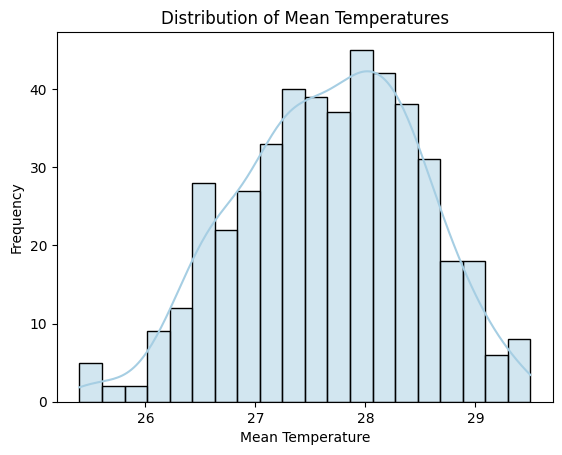

In [66]:
# Distribution of Mean Temperatures

plt.figure()
sns.histplot(df['mean_temp'], bins=20, kde=True)
plt.xlabel("Mean Temperature")
plt.ylabel("Frequency")
plt.title("Distribution of Mean Temperatures")
plt.show()

In [67]:
# Looking for Null Values
# No null values found

df.isnull().sum()

,0
mean_temp,0


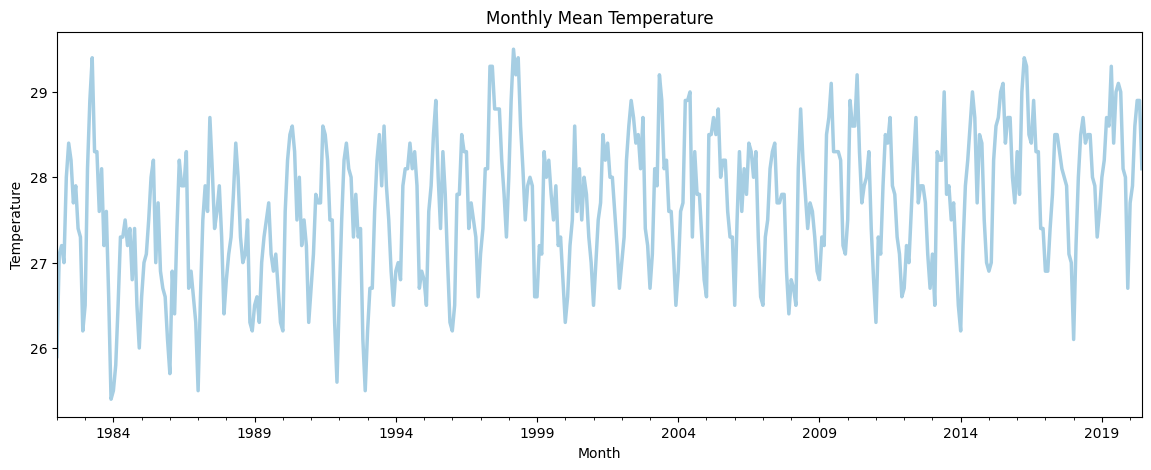

In [68]:
# Plot the monthly mean temperature trend over time

sns.set_palette("Paired")

df['mean_temp'].plot(figsize=(14,5), linewidth=2.5)
plt.title("Monthly Mean Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.show()

## **Rolling Statistics**
- Rolling Mean
- Rolling Standard Deviation

In [69]:
# Rolling mean and rolling standard deviation

df['rolling_mean'] = df['mean_temp'].rolling(12).mean() # Mean of past 12 months
# This smooths short-term fluctuations and highlights long-term trends.

df['rolling_std'] = df['mean_temp'].rolling(12).std() # Standard Deviation of 12 months

### If:
- 1. Rolling mean is flat
- 2. Rolling std is stable

Then the series is likely **Stationary**.

### If:
- 1. Rolling mean trends upward
- 2. Rolling std expands or contracts

Then differencing or transformation might be needed before modeling.

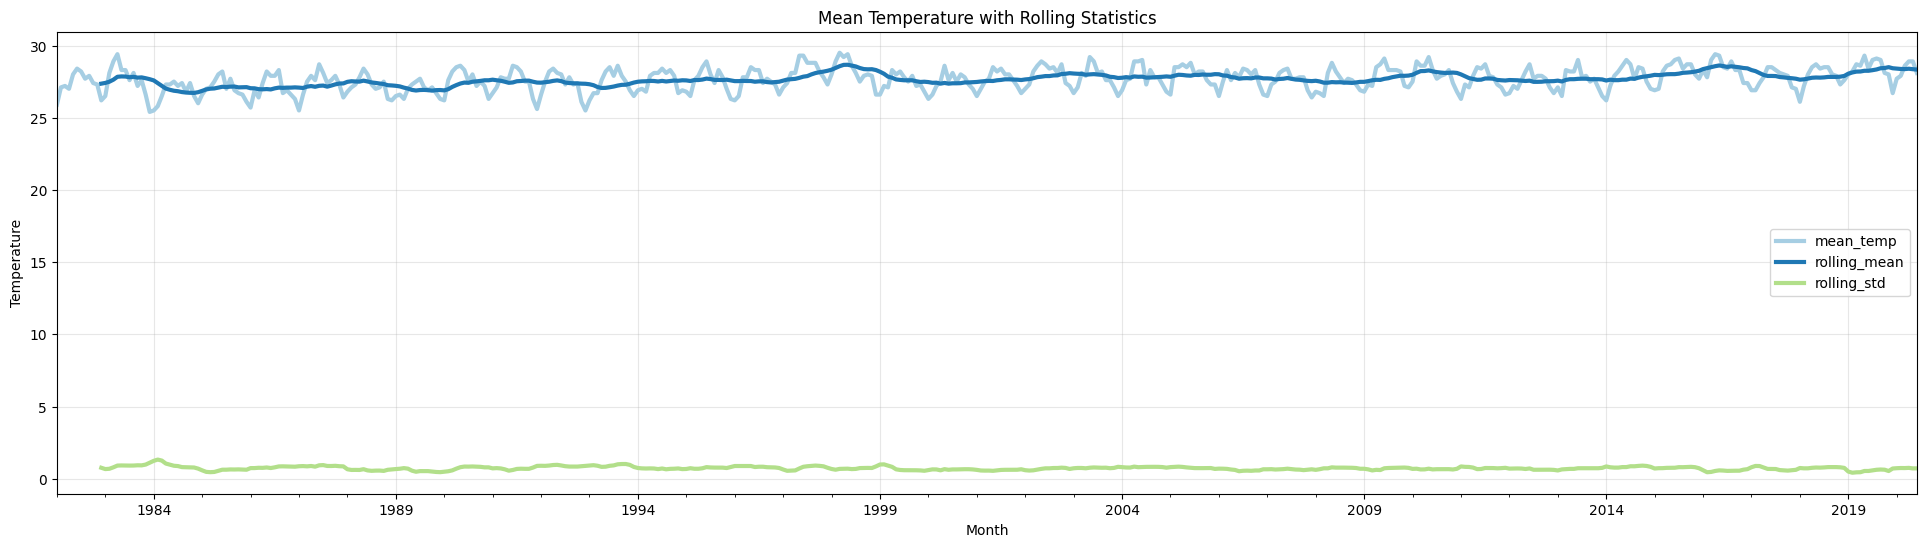

In [70]:
df[['mean_temp','rolling_mean','rolling_std']].plot(figsize=(24,6), linewidth=3)
plt.title("Mean Temperature with Rolling Statistics")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.grid(alpha=0.3)
plt.show()

In [71]:
# 11 values became NaN after rolling mean and rolling std

df.isna().sum()

,0
mean_temp,0
rolling_mean,11
rolling_std,11


In [72]:
# Clean dataframe after visualization
# we are:
# • Dropping the rolling_mean column
# • Dropping the rolling_std column
# • Keeping only the original temperature data
# • NaN (null) values also been treated

df = df[['mean_temp']]

In [73]:
df.isna().sum()

,0
mean_temp,0


## **Seasonal Decomposition**

It assumes time series can be written as:
- **Observed** = **Trend** + **Seasonality** + **Residual**
- Because we chose model='additive'.

### **model='additive'**

`Additive assumes:`
- Temperature = long-term trend
- repeating yearly pattern
- random noise
- This works well when seasonal fluctuations stay roughly the same size over time.

If seasonal swings grew larger as temperature increased, you'd use **model='multiplicative'** instead.

In [74]:
decomposition = seasonal_decompose(
    df['mean_temp'],
    model='additive',
    period=12, # 12 Observations per seasonal cycle, i.e one full seasonal cycle = 12 months
    extrapolate_trend='freq' # “Extrapolating the trend component so we don’t lose values at the start and end.” It reduces missing values in the trend output.
)

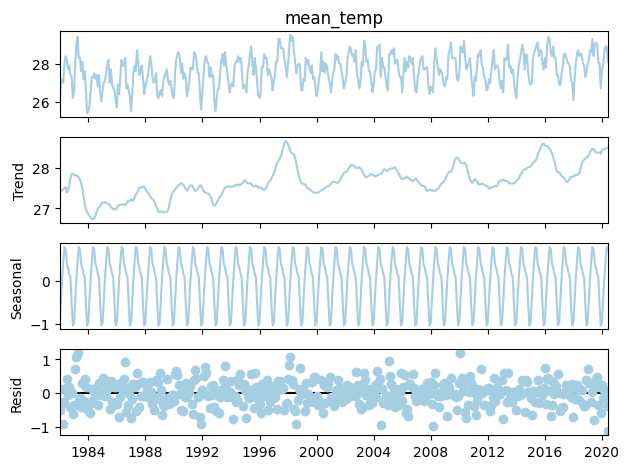

In [75]:
# Decomposed components Plot: observed, trend, seasonal, and residual

decomposition.plot()
plt.show()

# This generates four stacked plots:
    # Observed — original temperature series
    # Trend — long-term movement
    # Seasonal — repeating yearly pattern
    # Residual — what’s left after removing trend and seasonality

What we're actually looking for in the above plot:
1. `Trend:`
- Is temperature gradually increasing? Flat? Shifting?
2. `Seasonal:`
- Is there any consistent yearly oscillations?
- For temperature data, you should see smooth, repeating waves.
3. `Residual:`
- This is the “leftover chaos.”
- Ideally, it looks like random noise.
- If it still shows patterns, then the model's assumptions may be incomplete.

### *****AutoCorrelation Function*****

1. **Autocorrelation Function (ACF)** measures the ***total relationship*** between a ***time point*** (e.g., this month) and a ***past time*** point (e.g., k months ago), including both the ***direct connection*** and the ***indirect influence*** passed through all intermediate months.
2. ACF measures ***total correlation*** with past values (including indirect effects).
3. It calculates the correlation between:
    - Month t and Month t–k
    - But includes both direct and indirect effects (the "ripple effect" from intermediate lags).

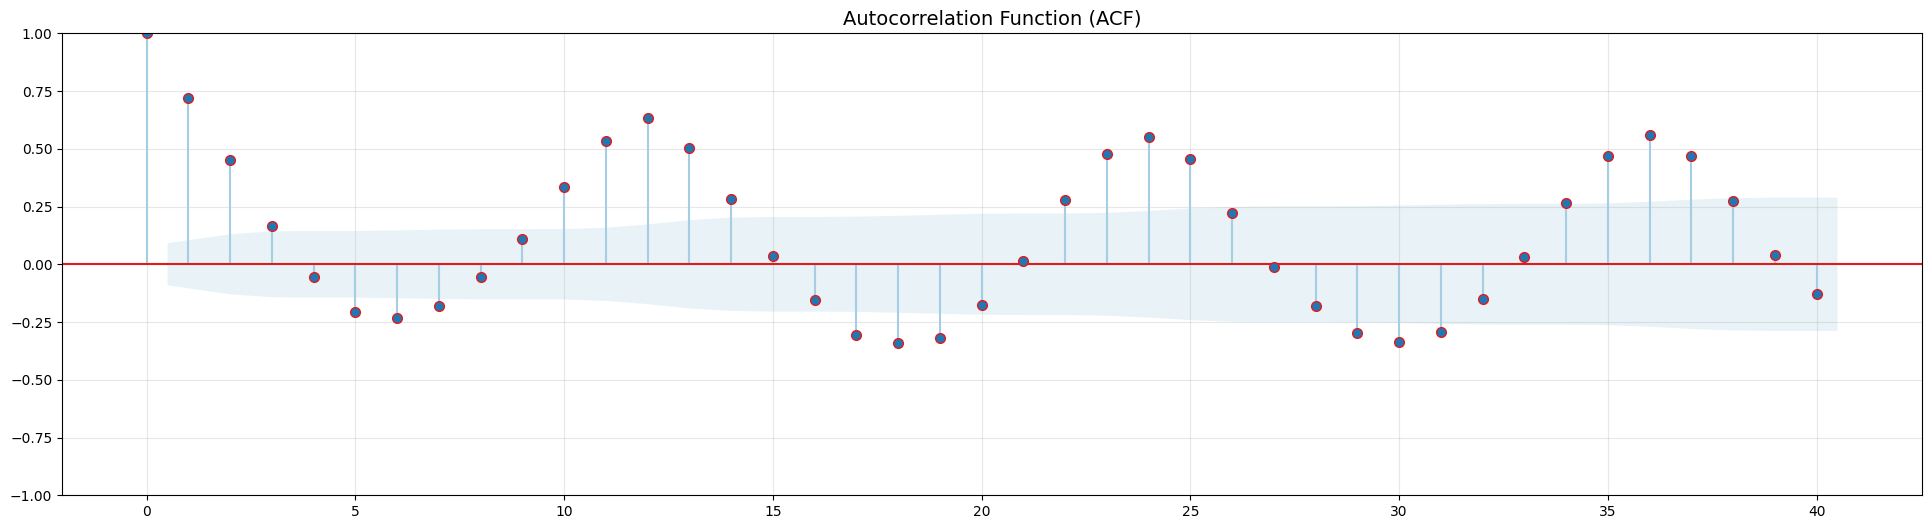

In [76]:
# Plotting the autocorrelation function to examine serial dependence up to 40 lags

palette = sns.color_palette("Paired")

fig, ax = plt.subplots(figsize=(24,6))

plot_acf(
    df['mean_temp'],
    lags=40,
    ax=ax,
    color=palette[5],
    markerfacecolor=palette[1],
    markersize=7
)

ax.set_title("Autocorrelation Function (ACF)", fontsize=14)
ax.grid(alpha=0.3)
plt.show()

### *****Partial AutoCorrelation Function*****

1. **Partial Autocorrelation Function (PACF)** measures the ***direct relationship*** between a ***time point*** (e.g., this month) and a **past time** point (e.g., k months ago), ***after removing*** the influence of the intermediate months.
2. PACF isolates only the ***direct effect***.
3. It calculates the correlation between:
    - Month t and Month t–k
    - But subtracts indirect correlations caused by the lags in between.

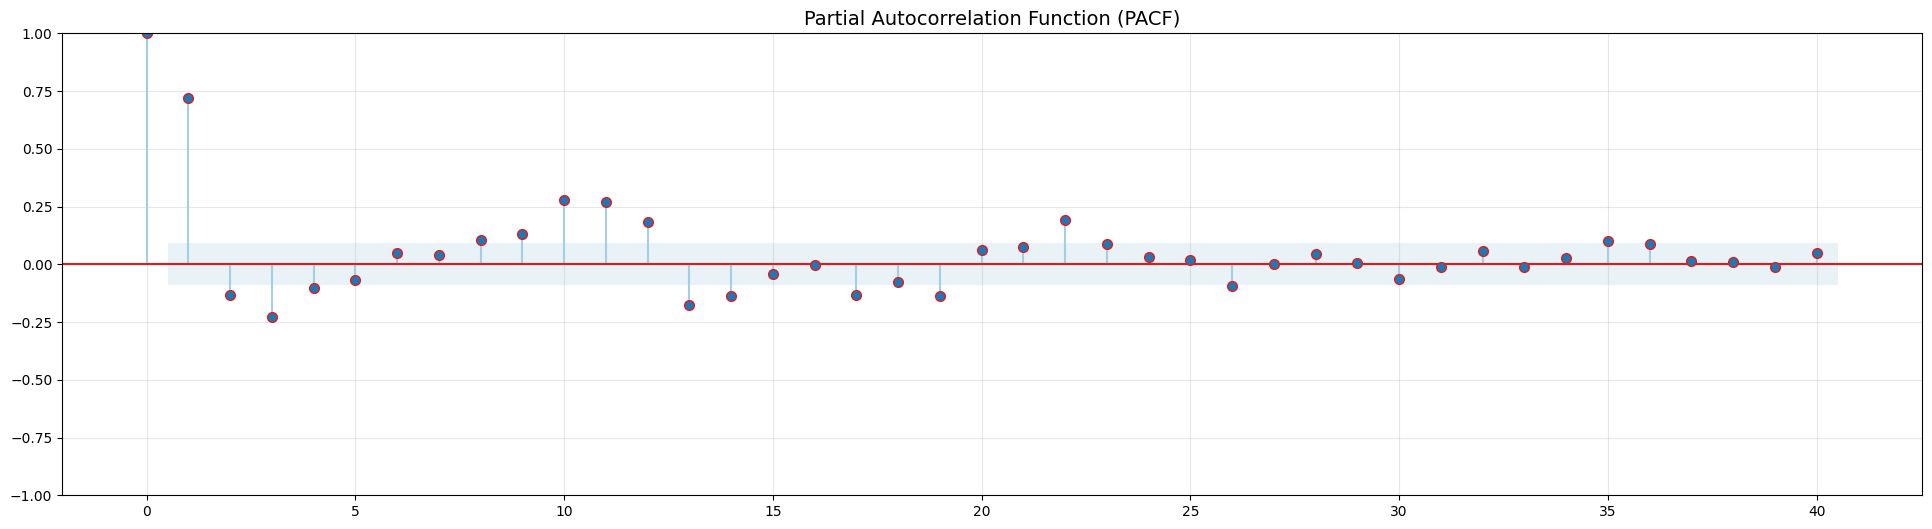

In [77]:
# Plotting the partial autocorrelation function to examine serial dependence up to 40 lags

palette = sns.color_palette("Paired")

fig, ax = plt.subplots(figsize=(24,6))

plot_pacf(
    df['mean_temp'],
    lags=40,
    ax=ax,
    color=palette[5],
    markerfacecolor=palette[1],
    markersize=7
)

ax.set_title("Partial Autocorrelation Function (PACF)", fontsize=14)
ax.grid(alpha=0.3)

plt.show()

- ACF helps decide the order of Moving Average (MA) terms.
- PACF helps decide the order of AutoRegressive (AR) terms.
- A strong PACF spike at lag 1 → AR(1) model; spike at lag 12 → seasonal AR term.

***Conclusion***: ACF shows how the past influences today overall, PACF shows which past months matter directly.

## Train-Test Split
- Chronological train-test split (80-20)

In [78]:
# Split the time series into training (80%) and testing (20%) sets

train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

In [79]:
# Print the date range of each set for verification

print("Train:", train.index.min(), "to", train.index.max())
print("Test:", test.index.min(), "to", test.index.max())

Train: 1982-01-01 00:00:00 to 2012-09-01 00:00:00
Test: 2012-10-01 00:00:00 to 2020-06-01 00:00:00


## Evaluation Function

In [80]:
# This function evaluates forecasting performance by comparing actual values

def evaluate_model(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100 # # Adding a tiny epsilon (1e-8) to prevent division by zero if true is 0.
    smape = np.mean(2 * np.abs(pred - true) / (np.abs(true) + np.abs(pred) + 1e-8)) * 100 # sMAPE (Symmetric Mean Absolute Percentage Error).

    print(f"{name} MAE:", mae)
    print(f"{name} RMSE:", rmse)
    print(f"{name} MAPE:", mape)
    print(f"{name} sMAPE:", smape)

    return mae, rmse, mape, smape

## ARIMA Model

In [81]:
# Train an ARIMA(1,1,1) model.
# Based on ADF test (d=1) and ACF/PACF inspection,
# a simple ARIMA(1,1,1) model was selected.

model_arima = ARIMA(train['mean_temp'], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary()) # summary of the fitted model including coefficients and diagnostics.

                               SARIMAX Results                                
Dep. Variable:              mean_temp   No. Observations:                  369
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -332.110
Date:                Fri, 06 Mar 2026   AIC                            670.220
Time:                        13:36:19   BIC                            681.945
Sample:                    01-01-1982   HQIC                           674.878
                         - 09-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.9812      0.024    -40.277      0.000      -1.029      -0.933
ma.L1          0.9522      0.038     24.881      0.000       0.877       1.027
sigma2         0.3557      0.028     12.820      0.0

In [82]:
# Forecasting for the test period using the trained ARIMA model

forecast_arima = model_arima_fit.forecast(steps=len(test))
forecast_arima = pd.Series(forecast_arima, index=test.index)

evaluate_model(test['mean_temp'], forecast_arima, "ARIMA")

ARIMA MAE: 0.6271050335797184
ARIMA RMSE: 0.7571495611206567
ARIMA MAPE: 2.2444936186309987
ARIMA sMAPE: 2.243823805984209


(0.6271050335797184,
 np.float64(0.7571495611206567),
 np.float64(2.2444936186309987),
 np.float64(2.243823805984209))

## SARIMA Model

### SARIMA Model Training

Training a **SARIMA (Seasonal AutoRegressive Integrated Moving Average)** model to forecast the **mean temperature** time series.

- `order=(1,1,1)` specifies the non-seasonal ARIMA parameters, where:
  - `1` autoregressive term (AR),
  - `1` differencing step to make the data stationary,
  - `1` moving average term (MA).
- `seasonal_order=(1,1,1,12)` adds seasonal components to capture repeating patterns every **12 time steps** (e.g., yearly seasonality in monthly data).
- `enforce_stationarity=False` and `enforce_invertibility=False` allow the model to fit even if strict statistical constraints are not satisfied.

In [83]:
model_sarima = SARIMAX(
    train['mean_temp'],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_sarima_fit = model_sarima.fit()

In [84]:
# Displays the summary of the trained SARIMA model.

print(model_sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                          mean_temp   No. Observations:                  369
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -188.693
Date:                            Fri, 06 Mar 2026   AIC                            387.387
Time:                                    13:36:23   BIC                            406.561
Sample:                                01-01-1982   HQIC                           395.025
                                     - 09-01-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2672      0.068      3.914      0.000       0.133       0.401
ma.L1         -0.8271      0.041   

In [85]:
# Forecasting for the test period using the trained SARIMA model

forecast_sarima = model_sarima_fit.forecast(steps=len(test))
forecast_sarima = pd.Series(forecast_sarima, index=test.index)

evaluate_model(test['mean_temp'], forecast_sarima, "SARIMA")

SARIMA MAE: 0.5302102882882861
SARIMA RMSE: 0.6618044772356916
SARIMA MAPE: 1.8758928832244286
SARIMA sMAPE: 1.9013974338738835


(0.5302102882882861,
 np.float64(0.6618044772356916),
 np.float64(1.8758928832244286),
 np.float64(1.9013974338738835))

## **Prophet Model**

In [86]:
prophet_df = df.reset_index() # Resets the index so the date becomes a column.
prophet_df.columns = ['ds', 'y']

cutoff_date = train.index.max() # Gets the last date of the training dataset.

In [87]:
# Splits the dataset into training and testing based on the cutoff date.

train_prophet = prophet_df[prophet_df['ds'] <= cutoff_date]
test_prophet = prophet_df[prophet_df['ds'] > cutoff_date]

In [88]:
# Model Fit

model_prophet = Prophet()
model_prophet.fit(train_prophet)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [89]:
# freq = 'MS' not used because Prophet internally expects end-of-period monthly frequency. Therefore, freq = 'M'

future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq='M') # Creates future dates for prediction.
forecast_prophet = model_prophet.predict(future) # Generates forecasted values.

forecast_test = forecast_prophet[forecast_prophet['ds'] > cutoff_date] # Selects only the predictions for the test period.

evaluate_model(test_prophet['y'], forecast_test['yhat'], "Prophet")

Prophet MAE: 0.5192693294221183
Prophet RMSE: 0.6617102995464699
Prophet MAPE: 1.840304546572528
Prophet sMAPE: 1.864360276615124


(0.5192693294221183,
 np.float64(0.6617102995464699),
 np.float64(1.840304546572528),
 np.float64(1.864360276615124))

## ML Lag Features
- Create lag features for ML models

In [90]:
# Creating a copy of the dataset for ML processing

df_ml = df.copy()

In [91]:
# Lag features convert time series into supervised learning format
# allowing ML models to learn patterns from past observations

In [92]:
# Creating Lag features from previous time stamps

for lag in [1,2,3,6,12]:
    df_ml[f'lag_{lag}'] = df_ml['mean_temp'].shift(lag)

df_ml.dropna(inplace=True)

In [93]:
# Data Split for ML Models

X = df_ml.drop(columns=['mean_temp'])
y = df_ml['mean_temp']

In [94]:
# Train-Test-Split

train_size_ml = int(len(df_ml) * 0.8)

X_train = X.iloc[:train_size_ml]
X_test = X.iloc[train_size_ml:]
y_train = y.iloc[:train_size_ml]
y_test = y.iloc[train_size_ml:]

## XGBoost

In [95]:
# Initialize model

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)

xgb_preds[:5]

array([26.821627, 27.427994, 27.09915 , 28.382954, 28.475992],
      dtype=float32)

In [96]:
# Xgboost model evaluation

evaluate_model(y_test, xgb_preds, "XGBoost")

XGBoost MAE: 0.45190501319037546
XGBoost RMSE: 0.5493881081945265
XGBoost MAPE: 1.6102132333683052
XGBoost sMAPE: 1.6184277632630508


(0.45190501319037546,
 np.float64(0.5493881081945265),
 np.float64(1.6102132333683052),
 np.float64(1.6184277632630508))

## Tuned XGBoost

In [97]:
# Creating a time-series cross-validation strategy with 3 splits.
tscv = TimeSeriesSplit(n_splits=3)

# Hyperparameter Tuning on XGBoost
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}
# Performing hyperparameter tuning by testing different parameter GridSearchCV combinations using cross-validation.
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_mean_absolute_error', # Using MAE as the evaluation metric for selecting the best model.
    cv=tscv, #   Applies time-series cross-validation during tuning.
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.03, 0.05], 'max_depth': [3, 4],
                         'n_estimators': [300, 500], 'subsample': [0.8, 1]},
             scoring='neg_mean_absolute_error')

In [98]:
# Retrieves the best-performing XGBoost model from the search, generating predictions & Evaluating.

xgb_best = grid_search.best_estimator_
xgb_tuned_preds = xgb_best.predict(X_test)

evaluate_model(y_test, xgb_tuned_preds, "Tuned XGBoost")

Tuned XGBoost MAE: 0.4437252044677734
Tuned XGBoost RMSE: 0.5412373135653535
Tuned XGBoost MAPE: 1.5811850339313285
Tuned XGBoost sMAPE: 1.5892003013123708


(0.4437252044677734,
 np.float64(0.5412373135653535),
 np.float64(1.5811850339313285),
 np.float64(1.5892003013123708))

## LightGBM

In [99]:
# LightGBM Model Initialization
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

# Train
lgb_model.fit(X_train, y_train)

# Predict
lgb_preds = lgb_model.predict(X_test)

lgb_preds[:5]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 175
[LightGBM] [Info] Number of data points in the train set: 360, number of used features: 5
[LightGBM] [Info] Start training from score 27.577778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

array([26.85138815, 27.5894595 , 27.07195049, 28.61018404, 28.41129411])

In [100]:
# LightGBM model evaluation

evaluate_model(y_test, lgb_preds, "LightGBM")

LightGBM MAE: 0.4406993733696011
LightGBM RMSE: 0.5479018077494852
LightGBM MAPE: 1.5728487500369017
LightGBM sMAPE: 1.5783466860843094


(0.4406993733696011,
 np.float64(0.5479018077494852),
 np.float64(1.5728487500369017),
 np.float64(1.5783466860843094))

## Tuned LightGBM

In [101]:
# Hyperparameter Tuning on LightGBM
param_grid_lgb = {
    'n_estimators': [300, 500],
    'learning_rate': [0.03, 0.05],
    'max_depth': [-1, 3],
    'num_leaves': [15, 31],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Performing hyperparameter tuning by testing different parameter GridSearchCV combinations using cross-validation.
lgb_grid = GridSearchCV(
    estimator=LGBMRegressor(random_state=42),
    param_grid=param_grid_lgb,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1
)

lgb_grid.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000051 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 175
[LightGBM] [Info] Number of data points in the train set: 360, number of used features: 5
[LightGBM] [Info] Start training from score 27.577778
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
             estimator=LGBMRegressor(random_state=42), n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.03, 0.05], 'max_depth': [-1, 3],
                         'n_estimators': [300, 500], 'num_leaves': [15, 31],
                         'subsample': [0.8, 1]},
             scoring='neg_mean_absolute_error')

In [102]:
# Retrieves the best-performing LightGBM model from the search, generating predictions & Evaluating.

lgb_best = lgb_grid.best_estimator_
lgb_tuned_preds = lgb_best.predict(X_test)

evaluate_model(y_test, lgb_tuned_preds, "Tuned LightGBM")

Tuned LightGBM MAE: 0.42262162895729477
Tuned LightGBM RMSE: 0.5322725588309205
Tuned LightGBM MAPE: 1.5067474088041486
Tuned LightGBM sMAPE: 1.5131999963217362


(0.42262162895729477,
 np.float64(0.5322725588309205),
 np.float64(1.5067474088041486),
 np.float64(1.5131999963217362))

## Hybrid Model - Hybrid SARIMA + XGBoost

In [103]:
# Getting the SARIMA model predictions on the training data.

sarima_train_pred = model_sarima_fit.fittedvalues

In [104]:
# Ensuring the training target and SARIMA predictions align.

common_index = y_train.index.intersection(sarima_train_pred.index)

In [105]:
# Calculating the residuals (errors) from the SARIMA model on the training set.
# And Aligning training features with residuals.

residuals_train = y_train.loc[common_index] - sarima_train_pred.loc[common_index]
X_train_aligned = X_train.loc[common_index]

In [106]:
# Intializing an XGBoost Model to learn the SARIMA residuals

xgb_residual = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    random_state=42
)

xgb_residual.fit(X_train_aligned, residuals_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [107]:
# Predicting residuals for the test set using XGBoost.

residuals_test = pd.Series(xgb_residual.predict(X_test), index=y_test.index)

# Aligning SARIMA forecasts and XGBoost residual predictions for the test set.
common_index_test = forecast_sarima.index.intersection(residuals_test.index)

In [108]:
# Combining SARIMA forecasts and XGBoost residuals to create hybrid predictions.
# And then Evaluating the hybrid model's performance.

hybrid_preds = (
    forecast_sarima.loc[common_index_test] +
    residuals_test.loc[common_index_test]
)

evaluate_model(y_test.loc[common_index_test], hybrid_preds, "Hybrid")

Hybrid MAE: 0.6213012185471791
Hybrid RMSE: 0.7618621939830467
Hybrid MAPE: 2.1953688818750803
Hybrid sMAPE: 2.228017383949959


(0.6213012185471791,
 np.float64(0.7618621939830467),
 np.float64(2.1953688818750803),
 np.float64(2.228017383949959))

## Final Comparison Table

In [109]:
# Evaluates all models (ARIMA, SARIMA, Prophet, XGBoost, Tuned XGBoost, LightGBM, Tuned LightGBM, and Hybrid)
# using the `evaluate_model()` function and stores MAE, RMSE, and MAPE for each.

results = {
    "ARIMA": evaluate_model(test['mean_temp'], forecast_arima, "ARIMA"),
    "SARIMA": evaluate_model(test['mean_temp'], forecast_sarima, "SARIMA"),
    "Prophet": evaluate_model(test_prophet['y'], forecast_test['yhat'], "Prophet"),
    "XGBoost": evaluate_model(y_test, xgb_preds, "XGBoost"),
    "Tuned XGBoost": evaluate_model(y_test, xgb_tuned_preds, "Tuned XGBoost"),
    "LightGBM": evaluate_model(y_test, lgb_preds, "LightGBM"),
    "Tuned LightGBM": evaluate_model(y_test, lgb_tuned_preds, "Tuned LightGBM"),
    "Hybrid": evaluate_model(y_test.loc[hybrid_preds.index], hybrid_preds, "Hybrid")
}

comparison_df = pd.DataFrame(results, index=["MAE", "RMSE", "MAPE", "sMAPE"]).T # Converting the result into a Dataframe for comparison.
comparison_df = comparison_df.sort_values(by="RMSE") #   Sorts the models by RMSE to quickly identify the best-performing model in terms of accuracy.

comparison_df

ARIMA MAE: 0.6271050335797184
ARIMA RMSE: 0.7571495611206567
ARIMA MAPE: 2.2444936186309987
ARIMA sMAPE: 2.243823805984209
SARIMA MAE: 0.5302102882882861
SARIMA RMSE: 0.6618044772356916
SARIMA MAPE: 1.8758928832244286
SARIMA sMAPE: 1.9013974338738835
Prophet MAE: 0.5192693294221183
Prophet RMSE: 0.6617102995464699
Prophet MAPE: 1.840304546572528
Prophet sMAPE: 1.864360276615124
XGBoost MAE: 0.45190501319037546
XGBoost RMSE: 0.5493881081945265
XGBoost MAPE: 1.6102132333683052
XGBoost sMAPE: 1.6184277632630508
Tuned XGBoost MAE: 0.4437252044677734
Tuned XGBoost RMSE: 0.5412373135653535
Tuned XGBoost MAPE: 1.5811850339313285
Tuned XGBoost sMAPE: 1.5892003013123708
LightGBM MAE: 0.4406993733696011
LightGBM RMSE: 0.5479018077494852
LightGBM MAPE: 1.5728487500369017
LightGBM sMAPE: 1.5783466860843094
Tuned LightGBM MAE: 0.42262162895729477
Tuned LightGBM RMSE: 0.5322725588309205
Tuned LightGBM MAPE: 1.5067474088041486
Tuned LightGBM sMAPE: 1.5131999963217362
Hybrid MAE: 0.6213012185471791
Hy

,MAE,RMSE,MAPE,sMAPE
Tuned LightGBM,0.422622,0.532273,1.506747,1.513200
Tuned XGBoost,0.443725,0.541237,1.581185,1.589200
LightGBM,0.440699,0.547902,1.572849,1.578347
XGBoost,0.451905,0.549388,1.610213,1.618428
Prophet,0.519269,0.661710,1.840305,1.864360
SARIMA,0.530210,0.661804,1.875893,1.901397
ARIMA,0.627105,0.757150,2.244494,2.243824
Hybrid,0.621301,0.761862,2.195369,2.228017
